In [9]:
if False:
    import pandas as pd

    # 1. Konstanten definieren
    EXPORT_DICT = {"id": "Eindeutige ID", "status": "Aktueller Status"}
    EXPORT_PARAMS = list(EXPORT_DICT.keys())
    EXPORT_DESCRIPTION = list(EXPORT_DICT.values())

    # 2. Beispiel-DataFrame definieren (damit er existiert)
    df_parameters = pd.DataFrame({
        "name": ["temp", "pressure"],
        "description": ["Temperatur in °C", "Druck in bar"]
    })

    # 3. Die Funktion definieren
    def extend_export_data(export_params, export_desc, df):
        # Wichtig: export_desc nutzen, nicht zweimal export_params erweitern
        export_params.extend([f"root.{param}" for param in df["name"].tolist()])
        export_desc.extend([f"{desc}" for desc in df["description"].tolist()])
        return export_params, export_desc

    print("KONSTANTEN (original):")
    print("EXPORT_PARAMS:", EXPORT_PARAMS)               
    print("EXPORT_DESCRIPTION:", EXPORT_DESCRIPTION)      

    # 4. Funktion ausführen
    neue_params, neue_beschreibungen = extend_export_data(
        EXPORT_PARAMS.copy(), 
        EXPORT_DESCRIPTION.copy(), 
        df_parameters
    )

    # 5. Überprüfung im Terminal
    print("\nNEUE LISTEN (erweitert):")
    print("neue_params:", neue_params)                 
    print("neue_beschreibungen:", neue_beschreibungen) 

    print("\nKONSTANTEN (unverändert):")
    print("EXPORT_PARAMS:", EXPORT_PARAMS)             
    print("EXPORT_DESCRIPTION:", EXPORT_DESCRIPTION)   


In [10]:
if False:
    import contextlib
    import os


    def unterliegende_funktion():
        print("Dieser Text wird standardmäßig gedruckt.")
        print("Dieser auch.")


    # Aufruf ohne Blockierung
    unterliegende_funktion()

    print("--- Start der Blockierung ---")

    # Hier werden alle Prints abgefangen und im "Nichts" versenkt
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull):
            unterliegende_funktion()  # Diese Prints siehst du nicht

    print("--- Ende der Blockierung ---")


In [11]:
if False:
    import contextlib
    import os

    # creat manager to suppress prints based on a boolean flag
    @contextlib.contextmanager
    def suppress_prints(should_suppress: bool):
        if should_suppress:
            # suppress the prints by redirecting stdout to os.devnull
            with open(os.devnull, "w") as fnull:
                with contextlib.redirect_stdout(fnull):
                    yield
        else:
            # allow prints to go through
            yield


    # --- BEISPIEL FÜR DIE ANWENDUNG ---


    def unterliegende_funktion():
        print("Hallo aus der Funktion!")


    # Steuerungs-Boolean
    print("--- Standard ---")
    unterliegende_funktion()  # Hier siehst du die Ausgabe

    stumm_schalten = True
    print("\n--- Test 1 (stumm_schalten = True) ---")
    with suppress_prints(stumm_schalten):
        unterliegende_funktion()  # Hier hörst du nichts

    print("\n--- Test 2 (stumm_schalten = False) ---")
    stumm_schalten = False
    with suppress_prints(stumm_schalten):
        unterliegende_funktion()  # Hier siehst du die Ausgabe


In [12]:
if False:
    import numpy as np
    np.linspace(0, -1e-6, 11)

In [13]:
if False:
    import numpy as np
    import pandas as pd


    def round_to_6_sig_digits(series: pd.Series) -> pd.Series:
        """Rounds a numeric pandas Series to exactly 6 significant digits."""
        valid_series = series.dropna()

        if valid_series.empty:
            return series

        abs_series = valid_series.abs()

        # If all non-NaN values are 0, return a series filled with 0.0
        if (abs_series == 0).all():
            return pd.Series(0.0, index=series.index)

        # Handle zeros carefully to avoid log10 infinity errors
        with np.errstate(divide="ignore"):
            exponent = np.where(abs_series > 0, np.floor(np.log10(abs_series)), 0)

        # 5 minus the exponent gives exactly 6 significant digits
        decimals = 5 - exponent.astype(int)

        # Compute rounded values while strictly preserving the DataFrame indices
        rounded_list = [
            round(val, max(0, dec)) if pd.notna(val) else np.nan
            for val, dec in zip(valid_series, decimals)
        ]

        return pd.Series(rounded_list, index=valid_series.index)


    def find_constant_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Identifies numeric columns in a DataFrame that contain only a single constant

        value within the first 25 rows, ignoring NaN values and checking up to 6
        significant digits. Non-numeric columns are skipped.
        """
        # Look only at the first 25 rows
        df_sample = df.head(25)
        constants_dict = {}

        for col in df_sample.columns:
            series = df_sample[col]

            # Skip non-numeric columns safely (handles StringDtype, object, datetime, etc.)
            if not pd.api.types.is_numeric_dtype(series.dtype):
                continue

            # Extract the series and explicitly drop NaN values
            valid_series = series.dropna()

            # Skip columns that are completely empty or contain only NaNs
            if valid_series.empty:
                continue

            # Round the remaining non-NaN values to 6 significant digits
            rounded_series = round_to_6_sig_digits(valid_series)

            # Check if all remaining valid values are identical after rounding
            if rounded_series.dropna().nunique() == 1:
                # Safely extract the first element as the scalar representation
                constants_dict[col] = rounded_series.dropna().iloc[0]

        # Construct the final resulting DataFrame
        return pd.DataFrame(
            list(constants_dict.items()), columns=["Constants", "Value"]
        )




    # Creating a test dataframe with various scenarios
    data = {
        # 1. Constant with floating-point errors (1/3 precision noise)
        "fp_constant": [0.33333333333333, 0.33333333333334, 0.33333333333332],
        # 2. Constant large numbers with small deviations beyond 6 sig digits
        "large_constant": [123456.1, 123456.2, 123456.3],  # rounds to 123456
        # 3. Constant small numbers with NaNs included
        "small_with_nan": [0.00001234567, np.nan, 0.00001234568],  # rounds to 0.0000123457
        # 4. Non-constant numeric column (should be skipped/ignored)
        "not_constant": [1.0, 2.0, 3.0],
        # 5. Non-numeric column (must be skipped entirely)
        "text_column": ["A", "A", "A"],
    }

    df_test = pd.DataFrame(data)

    print("Original DataFrame:")
    print(df_test)
    print("\n" + "=" * 40 + "\n")

    # Run the function
    result = find_constant_columns(df_test)

    print("Resulting DataFrame (Constants only):")
    print(result)

    # --- Test Configuration with Large and Small Scales ---
    print("\n" + "=" * 40 + "\n")
    data = {
        # 1. Constant around 1e3 with variations at the 7th digit (Should be captured)
        "large_const": [1234.561, 1234.562, 1234.563],
        # 2. Non-constant around 1e3 with variations at the 6th digit (Should be skipped)
        "large_diff": [1234.56, 1234.57, 1234.58],
        # 3. Constant around 1e-12 with variations at the 7th sig digit (Should be captured)
        "small_const": [1.234561e-12, 1.234562e-12, 1.234563e-12],
        # 4. Non-constant around 1e-12 with variations at the 6th sig digit (Should be skipped)
        "small_diff": [1.23456e-12, 1.23457e-12, 1.23458e-12],
        # 5. Dynamic mix with NaNs (Should be captured)
        "mix_nan": [12.34561, np.nan, 12.34562],
    }

    df_test = pd.DataFrame(data)
    result = find_constant_columns(df_test)

    print("Test with large and small scales:")
    print(result)


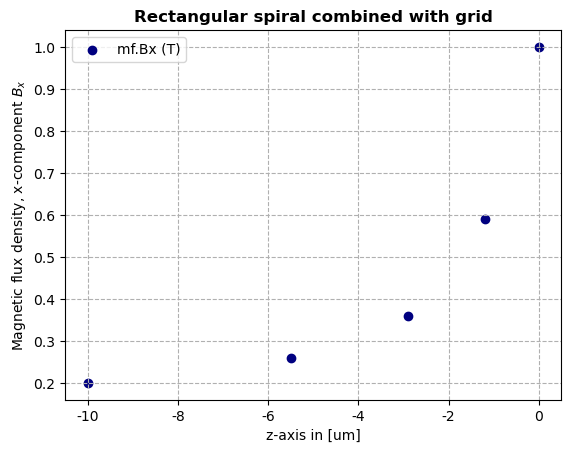

In [ ]:
if False:
    def get_SI_präfix(limits: tuple[float, float])-> tuple[str|None, int, int]:
        """
        Returns the SI prefix for a given numeric value.
        
        Args:
            limits (tuple[float, float]): A tuple containing the minimum and maximum values.
        
        Returns:
            tuple[str|None, int, int]: A tuple containing the SI prefix, the SI exponent, and the exponent difference to the magnitude of the input values.
        """
        # get the maximum absolute value from the limits
        xmax = max(abs(x) for x in limits)

        # get magnitude of the maximum value
        x_base_exponent = math.floor(math.log10(xmax)) if xmax > 0 else 0
        
        # Round down to the nearest multiple of 3 for SI prefix
        xsi_exponent = (x_base_exponent // 3) * 3 
        exponent_diff = x_base_exponent - xsi_exponent

        # Define the mapping of SI prefixes to their corresponding exponents
        PREFIX_TO_EXPONENT = {
            # Large values (positive exponents)
            "Q": 30,   # Quetta
            "R": 27,   # Ronna
            "Y": 24,   # Yotta
            "Z": 21,   # Zetta
            "E": 18,   # Exa
            "P": 15,   # Peta
            "T": 12,   # Tera
            "G": 9,    # Giga
            "M": 6,    # Mega
            "k": 3,    # Kilo
            "h": 2,    # Hecto
            "da": 1,   # Deca
            
            # Small values (negative exponents)
            "d": -1,   # Deci
            "c": -2,   # Centi
            "m": -3,   # Milli
            "u": -6,   # Micro (often written as µ)
            "n": -9,   # Nano
            "p": -12,  # Pico
            "f": -15,  # Femto
            "a": -18,  # Atto
            "z": -21,  # Zepto
            "y": -24,  # Yocto
            "r": -27,  # Ronto
            "q": -30,   # Quekto
        }

        # Returns the key, or None if the value doesn't exist
        sipräfix = next((k for k, v in PREFIX_TO_EXPONENT.items() if v == xsi_exponent), None)
        return sipräfix, xsi_exponent, exponent_diff


    import math
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    # --- Dein bestehender Code (Beispieldaten basierend auf deinem Bild) ---
    fig, ax = plt.subplots()
    x_data = [-1e-5, -5.5e-6, -2.9e-6, -1.2e-6, 0]
    y_data = [0.2, 0.26, 0.36, 0.59, 1.0]
    ax.scatter(x_data, y_data, color="navy", label="mf.Bx (T)")

    # --- AB HIER: Die saubere X-Achsen-Formatierung ---

    
    fig.canvas.draw()
    xlim = ax.get_xlim()
    sipräfix, xsi_exponent, exponent_diff = get_SI_präfix(xlim)
    scale_factor = 10 ** (-xsi_exponent)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x * scale_factor:g}"))

    ax.set_title("Rectangular spiral combined with grid", fontweight="bold")
    ax.set_xlabel(f"z-axis in [{sipräfix}m]")
    ax.set_ylabel("Magnetic flux density, x-component $B_x$")
    ax.grid(True, linestyle="--")
    ax.legend(loc="upper left")

    plt.show()


In [31]:
if True:
    import re
    def set_prefix_in_label(string, prefix="u"):
        if re.search(r"\[\w", string):
            return re.sub(r"\[(?=\w)", f"[{prefix}", string)
        elif re.search(r"\(\w", string):
            return re.sub(r"\((?=\w)", f"({prefix}", string)
        else:
            return f"{string} [{prefix}"

    strings = [
        r"Magnetic flux density  (x-component) $B_x$ [T]",
        r"Temperature $T$ [K]",
        r"Electric potential $U$ (V)",
        r"$z$-axis (depth) [m]",
        r"test"
    ]

    for s in strings:
        print(f"Original: {s}")
        neue_s = set_prefix_in_label(s, prefix="u")
        print(f"Mit Präfix: {neue_s}\n")


Original: Magnetic flux density  (x-component) $B_x$ [T]
Mit Präfix: Magnetic flux density  (x-component) $B_x$ [uT]

Original: Temperature $T$ [K]
Mit Präfix: Temperature $T$ [uK]

Original: Electric potential $U$ (V)
Mit Präfix: Electric potential $U$ (uV)

Original: $z$-axis (depth) [m]
Mit Präfix: $z$-axis (depth) [um]

Original: test
Mit Präfix: test [u

